# Experiments

## Imports

In [1]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import function_depot as fd

# DF7 creation

Here I need to create df7, which I may just choose to rename to be df6, but with one additonal column, 'synthetic' a dummy variable that will indicate if the dataframe is synthetic or real. That way I need not replace dataset names in my code and simply allow for the removal of all synthetic data by filtering on that variable. 

The process:
1. Merge the two data subsets so that df6 is a combination. This way I can use the same process as before to load in the spectra, the rounding and all and the only new addition is that that is the synthetic column as well.
2. Reload in the data, rounded as needed.
3. Load the new dataframes for each of the internal conditions. the fingerprints and all. 
4. Bin and threshold the large dataset appropriately. 


In [ ]:
# df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')

In [ ]:
# df6_subset.head()

## High Level Dataset Merger

In [25]:
# First we need to load in the two datasets. We need to remake the df6subset due to the errors before,
# to ensure everything is correct.
df6 = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/dataset_sep23.parquet')
print(df6.shape)
df6_synth = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/synthetic_spectra_2025_12_16_with_CE_clean.parquet')
print(df6_synth.shape)
df6_synth2 = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/synthetic_spectra_2.parquet')
print(df6_synth2.shape)

(24225, 21)
(413, 18)
(401, 18)


In [26]:
# Now take the subset of df6 we want and combine with the synthetic data.
# First order of business is to standardize our SMILES column. We want to use canonical smiles rather than SMILES_spectra but 
# we will keep the column name SMILES_spectra for consistency with previous code
df6 = df6.drop('SMILES_spectra', axis=1) # Drop
df6 = df6.rename(columns={'canonical_smiles_tox_vals': 'SMILES_spectra'}) # Rename
cols = df6.columns.tolist()
cols.remove('SMILES_spectra') 
df6 = df6[['SMILES_spectra'] + cols] # Move to front
# Next we want to standardize the Ionization column
# print(df6["Ionization_Mode"].unique()) # Check unique values
df6["Ionization_Mode"] = df6["Ionization_Mode"].replace("'Positive'", "'positive'") # Fix capitaliztion
df6 = df6[df6["Ionization_Mode"] != "'N/A'"] # Remove N/A 
# print(df6["Ionization_Mode"].unique()) # Check unique values

# Remove single quotes from all columns
df6 = df6.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)

# Select specific groups for subset
selected_groups = ['Q-Orbitrap-positive', 'Q-TOF-positive', 'LTQ-Orbitrap-positive']

# Create subset with only selected groups
df6_subset = df6[df6['Group'].isin(selected_groups)]

print(df6_subset.shape)

(15288, 20)


In [27]:
print(df6_subset.shape)
print(df6_synth.shape)
print(df6_synth2.shape)

(15288, 20)
(413, 18)
(401, 18)


In [28]:
print(df6_subset.columns)
print(df6_synth.columns)
print(df6_synth2.columns)

Index(['SMILES_spectra', 'CAS', 'Molecular_Formula', 'Total_Exact_Mass',
       'Precursor_m_z', 'Precursor_Type', 'Spectrum', 'Ionization_Mode',
       'Instrument_Type', 'Instrument_Name', 'Collision_Energy',
       'canonical_smiles_spectra', 'SMILES_tox', 'Response_Modifier',
       'Response', 'Response_Unit', 'Group', 'CE_clean', 'fp', 'filtered_fp'],
      dtype='object')
Index(['SMILES_spectra', 'CAS', 'Molecular_Formula', 'Total_Exact_Mass',
       'Precursor_m_z', 'Precursor_Type', 'Spectrum', 'Ionization_Mode',
       'Instrument_Type', 'Instrument_Name', 'Collision_energy',
       'Response_Modifier', 'Response', 'Response_Unit', 'Group', 'CE_clean',
       'fp', 'filtered_fp'],
      dtype='object')
Index(['SMILES_spectra', 'CAS', 'Molecular_Formula', 'Total_Exact_Mass',
       'Precursor_m_z', 'Precursor_Type', 'Spectrum', 'Ionization_Mode',
       'Instrument_Type', 'Instrument_Name', 'Collision_energy',
       'Response_Modifier', 'Response', 'Response_Unit', 'Group', '

In [20]:
df6_synth_copy = df6_synth.copy()
df6_synth2_copy = df6_synth2.copy()
print(df6_synth_copy.shape)
print(df6_synth2_copy.shape)

(413, 18)
(401, 18)


In [12]:
# Filter df6_synth to keep only rows where Collision_energy is between 30 and 45
print(f"Original df6_synth shape: {df6_synth.shape}")
print(f"Collision_energy range in df6_synth: {df6_synth['Collision_energy'].min()} to {df6_synth['Collision_energy'].max()}")

# Keep rows where Collision_energy is between 30 and 45 (inclusive)
df6_synth = df6_synth[(df6_synth['Collision_energy'] >= 30) & (df6_synth['Collision_energy'] <= 45)]

print(f"Filtered df6_synth shape: {df6_synth.shape}")
print(f"New Collision_energy range in df6_synth: {df6_synth['Collision_energy'].min()} to {df6_synth['Collision_energy'].max()}")

print("\n" + "="*50 + "\n")

# Filter df6_synth2 to keep only rows where Collision_energy is less than 80
print(f"Original df6_synth2 shape: {df6_synth2.shape}")
print(f"Collision_energy range in df6_synth2: {df6_synth2['Collision_energy'].min()} to {df6_synth2['Collision_energy'].max()}")

# Keep rows where Collision_energy is less than 80
df6_synth2 = df6_synth2[df6_synth2['Collision_energy'] < 80]

print(f"Filtered df6_synth2 shape: {df6_synth2.shape}")
print(f"New Collision_energy range in df6_synth2: {df6_synth2['Collision_energy'].min()} to {df6_synth2['Collision_energy'].max()}")

Original df6_synth shape: (413, 18)
Collision_energy range in df6_synth: 20 to 80
Filtered df6_synth shape: (236, 18)
New Collision_energy range in df6_synth: 30 to 45


Original df6_synth2 shape: (401, 18)
Collision_energy range in df6_synth2: 20 to 80
Filtered df6_synth2 shape: (347, 18)
New Collision_energy range in df6_synth2: 20 to 60


In [29]:
# Remove rows where CE_clean is 'calc' from df6
print(f"Original df6 shape: {df6_subset.shape}")
print(f"CE_clean values before filtering: {df6_subset['CE_clean'].value_counts()}")

# Filter out rows where CE_clean equals 'calc'
df6_subset = df6_subset[df6_subset['CE_clean'] != 'calc']
print(f"Filtered df6 shape: {df6_subset.shape}")
print(f"CE_clean values after filtering: {df6_subset['CE_clean'].value_counts()}")
print(f"Removed {df6_subset.shape[0]} rows where CE_clean was 'calc'")

Original df6 shape: (15288, 20)
CE_clean values before filtering: CE_clean
low       7718
medium    5142
NAN       1265
high      1161
calc         2
Name: count, dtype: int64
Filtered df6 shape: (15286, 20)
CE_clean values after filtering: CE_clean
low       7718
medium    5142
NAN       1265
high      1161
Name: count, dtype: int64
Removed 15286 rows where CE_clean was 'calc'


In [30]:
# Standardize column names - rename 'Collision_Energy' to 'Collision_energy' in df6_subset
if 'Collision_Energy' in df6_subset.columns:
    df6_subset = df6_subset.rename(columns={'Collision_Energy': 'Collision_energy'})

# Find common columns across all three dataframes
common_columns = set(df6_subset.columns) & set(df6_synth.columns) & set(df6_synth2.columns)
common_columns = list(common_columns)
print(f"Common columns: {len(common_columns)}")

# Keep only common columns in df6_subset
df6_subset = df6_subset[common_columns]

# Add synthetic column (0 for real data, 1 for synthetic data)
df6_subset['synthetic'] = 0
df6_synth['synthetic'] = 1
df6_synth2['synthetic'] = 1

print(f"df6_subset shape after processing: {df6_subset.shape}")
print(f"df6_synth shape after adding synthetic column: {df6_synth.shape}")
print(f"df6_synth2 shape after adding synthetic column: {df6_synth2.shape}")

Common columns: 18
df6_subset shape after processing: (15286, 19)
df6_synth shape after adding synthetic column: (413, 19)
df6_synth2 shape after adding synthetic column: (401, 19)


In [31]:
# Save the existing df6_subset as df6_subset_real
df6_subset_real = df6_subset.copy()
print(f"Saved original df6_subset as df6_subset_real with shape: {df6_subset_real.shape}")
# df6_subset_real.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset_real.parquet')
# Combine all three dataframes vertically into new df6_subset
df6_subset = pd.concat([df6_subset, df6_synth, df6_synth2], 
                      ignore_index=True, sort=False)

print(f"Combined dataframe shapes:")
print(f"  df6_subset_real: {df6_subset_real.shape}")
print(f"  df6_synth: {df6_synth.shape}") 
print(f"  df6_synth2: {df6_synth2.shape}")
print(f"  New combined df6_subset: {df6_subset.shape}")

# Verify synthetic column distribution
print(f"\nSynthetic column distribution in new df6_subset:")
print(df6_subset['synthetic'].value_counts())

Saved original df6_subset as df6_subset_real with shape: (15286, 19)
Combined dataframe shapes:
  df6_subset_real: (15286, 19)
  df6_synth: (413, 19)
  df6_synth2: (401, 19)
  New combined df6_subset: (16100, 19)

Synthetic column distribution in new df6_subset:
synthetic
0    15286
1      814
Name: count, dtype: int64


In [39]:
print(df6_subset.shape)
df6_subset.head()
df6_subset.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')

(16100, 6)


In [37]:
# Define the desired column order
desired_columns = ['SMILES_spectra',  'Response', 'Group', 'CE_clean',
                   'fp', 'filtered_fp']

# Check which columns exist in df6_subset
existing_columns = [col for col in desired_columns if col in df6_subset.columns]
missing_columns = [col for col in desired_columns if col not in df6_subset.columns]

print(f"Existing columns: {len(existing_columns)}")
print(f"Missing columns: {missing_columns}")

# Reorder df6_subset with existing columns only
df6_subset = df6_subset[existing_columns]

print(f"df6_subset reordered with shape: {df6_subset.shape}")
print(f"New column order: {list(df6_subset.columns)}")

Existing columns: 6
Missing columns: []
df6_subset reordered with shape: (16100, 6)
New column order: ['SMILES_spectra', 'Response', 'Group', 'CE_clean', 'fp', 'filtered_fp']


# Testing!

In [40]:
# Load both dataframes
df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')

print(f"df6_spectra shape: {df6_spectra.shape}")
print(f"df6_subset shape: {df6_subset.shape}")

# Get unique SMILES from both dataframes
spectra_smiles = set(df6_spectra['SMILES_spectra'].unique())
subset_smiles = set(df6_subset['SMILES_spectra'].unique())

print(f"\nUnique SMILES in df6_spectra: {len(spectra_smiles)}")
print(f"Unique SMILES in df6_subset: {len(subset_smiles)}")

# Find common SMILES
common_smiles = spectra_smiles & subset_smiles
print(f"Common SMILES between both datasets: {len(common_smiles)}")

# Find SMILES only in df6_spectra
only_in_spectra = spectra_smiles - subset_smiles
print(f"SMILES only in df6_spectra: {len(only_in_spectra)}")

# Find SMILES only in df6_subset
only_in_subset = subset_smiles - spectra_smiles
print(f"SMILES only in df6_subset: {len(only_in_subset)}")

# Show some examples if there are differences
if only_in_spectra:
    print(f"\nFirst 5 SMILES only in df6_spectra:")
    for smiles in list(only_in_spectra)[:5]:
        print(f"  {smiles}")

if only_in_subset:
    print(f"\nFirst 5 SMILES only in df6_subset:")
    for smiles in list(only_in_subset)[:5]:
        print(f"  {smiles}")

# Check if datasets are perfectly aligned
if len(only_in_spectra) == 0 and len(only_in_subset) == 0:
    print(f"\n✓ PERFECT MATCH: Both datasets have exactly the same unique SMILES")
else:
    print(f"\n✗ MISMATCH: Datasets have different SMILES entries")

# Additional analysis: Check row counts per SMILES
print(f"\n=== ROW COUNT ANALYSIS ===")
spectra_counts = df6_spectra['SMILES_spectra'].value_counts()
subset_counts = df6_subset['SMILES_spectra'].value_counts()

print(f"SMILES with multiple rows in df6_spectra: {sum(spectra_counts > 1)}")
print(f"SMILES with multiple rows in df6_subset: {sum(subset_counts > 1)}")

# For common SMILES, compare row counts
if common_smiles:
    print(f"\n=== ROW COUNT COMPARISON FOR COMMON SMILES ===")
    count_mismatches = 0
    for smiles in list(common_smiles)[:10]:  # Check first 10 common SMILES
        spectra_count = spectra_counts.get(smiles, 0)
        subset_count = subset_counts.get(smiles, 0)
        if spectra_count != subset_count:
            count_mismatches += 1
            print(f"  {smiles}: df6_spectra={spectra_count}, df6_subset={subset_count}")
    
    if count_mismatches == 0:
        print("  ✓ Row counts match for all common SMILES (checked first 10)")
    else:
        print(f"  ✗ Row count mismatches found for {count_mismatches} SMILES")

# Summary statistics
print(f"\n=== SUMMARY ===")
print(f"Total unique SMILES across both datasets: {len(spectra_smiles | subset_smiles)}")
print(f"Overlap percentage: {len(common_smiles) / len(spectra_smiles | subset_smiles) * 100:.2f}%")

df6_spectra shape: (15869, 54914)
df6_subset shape: (16100, 6)

Unique SMILES in df6_spectra: 1419
Unique SMILES in df6_subset: 1419
Common SMILES between both datasets: 1419
SMILES only in df6_spectra: 0
SMILES only in df6_subset: 0

✓ PERFECT MATCH: Both datasets have exactly the same unique SMILES

=== ROW COUNT ANALYSIS ===
SMILES with multiple rows in df6_spectra: 1255
SMILES with multiple rows in df6_subset: 1255

=== ROW COUNT COMPARISON FOR COMMON SMILES ===
  CCOC(=O)C1(c2ccccc2)CCN(C)CC1: df6_spectra=16, df6_subset=20
  ✗ Row count mismatches found for 1 SMILES

=== SUMMARY ===
Total unique SMILES across both datasets: 1419
Overlap percentage: 100.00%


In [24]:
print(df6_spectra['synthetic'].value_counts())

synthetic
0    15286
1      583
Name: count, dtype: int64


## Internal conditions dataframes

In [ ]:
# # CHEMNET EMBEDDINGS
# # Create ChemNet embeddings dataframe using get_chemnet_emb_from_smiles
# unique_smiles = df6_subset['SMILES_spectra'].unique().tolist()
# print(f"Getting ChemNet embeddings for {len(unique_smiles)} unique SMILES...")

# # Get embeddings dictionary
# embeddings_dict = fd.get_chemnet_emb_from_smiles(unique_smiles)

# # Convert to dataframe format
# embeddings_data = []
# for smiles, embedding in embeddings_dict.items():
#     if embedding != 'unknown':  # Skip unknown embeddings
#         row = {'SMILES_spectra': smiles}
#         # Add each embedding dimension as a separate column
#         for i, emb_val in enumerate(embedding):
#             row[f'Embedding Float {i}'] = emb_val
#         embeddings_data.append(row)

# df6_chemnet = pd.DataFrame(embeddings_data)

# print("\n=== EMBEDDINGS DATAFRAME ===")
# print(f"Shape: {df6_chemnet.shape}")
# print(f"Unique SMILES: {df6_chemnet['SMILES_spectra'].nunique()}")
# print(f"Embedding dimensions: {df6_chemnet.shape[1] - 1}")  # -1 for SMILES column

# # MORGAN FINGERPRINTS
# # Create dataframe with just SMILES and Morgan fingerprints using expand_fingerprints_to_matrix
# df6_morganfp= fd.expand_fingerprints_to_matrix(df6_subset, smiles_col='SMILES_spectra', fp_col='fp')

# print("\n=== FINGERPRINTS DATAFRAME ===")
# print(f"Shape: {df6_morganfp.shape}")
# print(f"Unique SMILES: {df6_morganfp['SMILES_spectra'].nunique()}")

# # FILTERED MORGAN FINGERPRINTS
# # Create dataframe with just SMILES and Morgan fingerprints using expand_fingerprints_to_matrix
# df6_filtered_morganfp= fd.expand_fingerprints_to_matrix(df6_subset, smiles_col='SMILES_spectra', fp_col='filtered_fp')

# print("\n=== FINGERPRINTS DATAFRAME ===")
# print(f"Shape: {df6_filtered_morganfp.shape}")
# print(f"Unique SMILES: {df6_filtered_morganfp['SMILES_spectra'].nunique()}")

In [ ]:
# df6_chemnet.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet.parquet', index=False)
# df6_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp.parquet', index=False)
# df6_filtered_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp.parquet', index=False)

In [ ]:
# df6_chemnet = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet.parquet')
# print(df6_chemnet.shape)
# df6_chemnet.head()

In [ ]:
# df6_morganfp = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp.parquet')
# print(df6_morganfp.shape)
# df6_morganfp.head()

In [ ]:
# df6_filtered_morganfp = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp.parquet')
# print(df6_filtered_morganfp.shape) 
# df6_filtered_morganfp.head()

## Set up spectra dataframe

In [ ]:
def pre_filter_and_round_spectrum_mz_synth(df, spectrum_col, min_mz=0, max_mz=1000, round_precision=0.001):
    """
    Pre-filter a DataFrame by removing m/z values outside the specified range AND round m/z values 
    to the nearest specified precision from spectrum strings.
    This reduces memory usage before processing with spectrum_string_to_dataframe.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame with spectrum data
    spectrum_col : str
        Name of the column containing spectrum strings
    min_mz : float, optional
        Minimum m/z value to keep. Default is 0.
    max_mz : float, optional
        Maximum m/z value to keep. Default is 1000.
    round_precision : float, optional
        Precision to round m/z values to. Default is 0.001.
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with filtered and rounded spectrum strings
    """
    def filter_and_round_spectrum_string_synth(spectrum_str, min_mz, max_mz, round_precision):
        if pd.isna(spectrum_str):
            return ""
        
        pairs = spectrum_str.split()
        filtered_pairs = []
        
        for pair in pairs:
            try:
                x, y = pair.split(":")
                mz_value = float(x)
                
                # First filter by range
                if min_mz <= mz_value <= max_mz:
                    # Then round to specified precision
                    rounded_mz = round(mz_value / round_precision) * round_precision
                    # Format to avoid floating point precision issues
                    rounded_mz_str = f"{rounded_mz:.3f}"
                    
                    # CHANGE: Multiply intensity by 100 to correct scale before reconstruction
                    intensity_corrected = float(y) * 100
                    filtered_pairs.append(f"{rounded_mz_str}:{intensity_corrected}")
            except:
                continue
        
        return " ".join(filtered_pairs)
    
    df_filtered = df.copy()
    print(f"Filtering {len(df)} rows, keeping m/z values between {min_mz} and {max_mz}, rounding to nearest {round_precision}...")
    df_filtered[spectrum_col] = df_filtered[spectrum_col].apply(
        lambda x: filter_and_round_spectrum_string_synth(x, min_mz, max_mz, round_precision)
    )
    print("Filtering and rounding complete.")
    
    return df_filtered

In [ ]:
df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')
df6_synth = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_synth.parquet')
df6_synth2 = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_synth2.parquet')


In [ ]:
# SPECTRA DATAFRAME
print("Creating spectra dataframe...")
# Create dataframe with spectra using spectrum_string_to_dataframe
df_filtered = fd.pre_filter_and_round_spectrum_mz(df=df6_subset, spectrum_col='Spectrum',min_mz=0, max_mz=1500, round_precision=0.01)
print("Starting conversion of spectrum strings to dataframe...")
df6_spectra = fd.spectrum_string_to_dataframe(df_filtered, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

# SYNTH SPECTRA DATAFRAME
print("Creating spectra dataframe...")
# Create dataframe with spectra using spectrum_string_to_dataframe
df_filtered_synth = pre_filter_and_round_spectrum_mz_synth(df=df6_synth, spectrum_col='Spectrum',min_mz=0, max_mz=1500, round_precision=0.01)
print("Starting conversion of spectrum strings to dataframe...")
df6_spectra_synth = fd.spectrum_string_to_dataframe(df_filtered_synth, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

# SYNTH2 SPECTRA DATAFRAME
print("Creating spectra dataframe...")
# Create dataframe with spectra using spectrum_string_to_dataframe
df_filtered_synth2 = pre_filter_and_round_spectrum_mz_synth(df=df6_synth2, spectrum_col='Spectrum',min_mz=0, max_mz=1500, round_precision=0.01)
print("Starting conversion of spectrum strings to dataframe...")
df6_spectra_synth2 = fd.spectrum_string_to_dataframe(df_filtered_synth2, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

In [ ]:
# Add columns back to df6_spectra from df6_subset
df6_spectra['Group'] = df6_subset['Group'].values
df6_spectra['Response'] = df6_subset['Response'].values
df6_spectra['CE_clean'] = df6_subset['CE_clean'].values
df6_spectra['synthetic'] = df6_subset['synthetic'].values

# Add columns back to df6_spectra_synth from df6_synth
df6_spectra_synth['Group'] = df6_synth['Group'].values
df6_spectra_synth['Response'] = df6_synth['Response'].values
df6_spectra_synth['CE_clean'] = df6_synth['CE_clean'].values
df6_spectra_synth['synthetic'] = df6_synth['synthetic'].values

# Add columns back to df6_spectra_synth2 from df6_synth2
df6_spectra_synth2['Group'] = df6_synth2['Group'].values
df6_spectra_synth2['Response'] = df6_synth2['Response'].values
df6_spectra_synth2['CE_clean'] = df6_synth2['CE_clean'].values
df6_spectra_synth2['synthetic'] = df6_synth2['synthetic'].values

print("Columns added back to all spectra dataframes:")
print(f"df6_spectra shape: {df6_spectra.shape}")
print(f"df6_spectra_synth shape: {df6_spectra_synth.shape}")
print(f"df6_spectra_synth2 shape: {df6_spectra_synth2.shape}")

In [ ]:
print(df6_spectra.shape)
print(df6_spectra_synth.shape)
print(df6_spectra_synth2.shape)

In [ ]:
df6_spectra.head()

In [ ]:
df6_spectra_synth.head()

In [ ]:
df6_spectra_synth2.head()

In [ ]:
# Remove index_id column from each of the three datasets
if 'index_id' in df6_spectra.columns:
    df6_spectra = df6_spectra.drop('index_id', axis=1)
    print("Removed index_id from df6_spectra")

if 'index_id' in df6_spectra_synth.columns:
    df6_spectra_synth = df6_spectra_synth.drop('index_id', axis=1)
    print("Removed index_id from df6_spectra_synth")

if 'index_id' in df6_spectra_synth2.columns:
    df6_spectra_synth2 = df6_spectra_synth2.drop('index_id', axis=1)
    print("Removed index_id from df6_spectra_synth2")

In [ ]:
# Define metadata columns to preserve
metadata_columns = ['SMILES_spectra', 'Group', 'CE_clean', 'Response', 'synthetic']

# Get all unique spectral columns (excluding metadata columns)
all_spectral_columns = set()
for df in [df6_spectra, df6_spectra_synth, df6_spectra_synth2]:
    spectral_cols = [col for col in df.columns if col not in metadata_columns]
    all_spectral_columns.update(spectral_cols)

# Convert spectral column names to floats and sort numerically from low to high
def sort_key(col):
    try:
        return float(col)
    except:
        return float('inf')  # Put non-numeric columns at the end

all_spectral_columns = sorted(list(all_spectral_columns), key=sort_key)

# Convert column names to floats where possible
float_spectral_columns = []
for col in all_spectral_columns:
    try:
        float_spectral_columns.append(float(col))
    except:
        float_spectral_columns.append(col)  # Keep original if can't convert

# Add missing spectral columns to each dataframe and fill with zeros
for i, col in enumerate(all_spectral_columns):
    float_col = float_spectral_columns[i]
    if col not in df6_spectra.columns:
        df6_spectra[float_col] = 0.0
    else:
        df6_spectra[float_col] = df6_spectra[col].astype(float)
        if col != float_col:
            df6_spectra = df6_spectra.drop(col, axis=1)
    
    if col not in df6_spectra_synth.columns:
        df6_spectra_synth[float_col] = 0.0
    else:
        df6_spectra_synth[float_col] = df6_spectra_synth[col].astype(float)
        if col != float_col:
            df6_spectra_synth = df6_spectra_synth.drop(col, axis=1)
    
    if col not in df6_spectra_synth2.columns:
        df6_spectra_synth2[float_col] = 0.0
    else:
        df6_spectra_synth2[float_col] = df6_spectra_synth2[col].astype(float)
        if col != float_col:
            df6_spectra_synth2 = df6_spectra_synth2.drop(col, axis=1)

# Create final column order: metadata columns first, then sorted float spectral columns
final_column_order = metadata_columns + float_spectral_columns

# Reorder columns to be consistent across all dataframes
df6_spectra = df6_spectra[final_column_order]
df6_spectra_synth = df6_spectra_synth[final_column_order]
df6_spectra_synth2 = df6_spectra_synth2[final_column_order]

# Combine all three dataframes vertically
df6_spectra_combined = pd.concat([df6_spectra, df6_spectra_synth, df6_spectra_synth2], 
                                ignore_index=True, sort=False)

print(f"Combined dataframe shape: {df6_spectra_combined.shape}")
print(f"Total rows: {len(df6_spectra)} + {len(df6_spectra_synth)} + {len(df6_spectra_synth2)} = {len(df6_spectra_combined)}")
print(f"Total spectral columns: {len(float_spectral_columns)}")
print(f"Total columns (including metadata): {len(final_column_order)}")
print(f"Spectral columns range from {min(float_spectral_columns)} to {max(float_spectral_columns)}")

# Add new index_id to the combined dataframe
df6_spectra_combined['index_id'] = range(len(df6_spectra_combined))

print(f"Added new index_id to combined dataframe with range 0 to {len(df6_spectra_combined)-1}")
print(f"Final combined dataframe shape: {df6_spectra_combined.shape}")

In [ ]:
# Move Group, CE_clean, Response, and synthetic columns to the end
columns_to_move = ['Group', 'CE_clean', 'Response', 'synthetic']
other_columns = [col for col in df6_spectra_combined.columns if col not in columns_to_move]
new_column_order = other_columns + columns_to_move

# Reorder the dataframe
df6_spectra_combined = df6_spectra_combined[new_column_order]

print(f"Moved columns {columns_to_move} to the end")
print(f"New column order (last 10): {list(df6_spectra_combined.columns)[-10:]}")
print(f"Dataframe shape: {df6_spectra_combined.shape}")

In [ ]:
df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
df6_spectra.head()

In [ ]:
# # SPECTRA DATAFRAME - Create ranges with proper column management
# print("Creating spectra dataframe ranges with column management...")

# # Add columns to range 1
# smiles_to_group = df6_subset.set_index('SMILES_spectra')['Group'].to_dict()
# smiles_to_response = df6_subset.set_index('SMILES_spectra')['Response'].to_dict()
# smiles_to_ce_clean = df6_subset.set_index('SMILES_spectra')['CE_clean'].to_dict()
# smiles_to_synthetic = df6_subset.set_index('SMILES_spectra')['synthetic'].to_dict()

# df6_spectra_range1['Group'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_group)
# df6_spectra_range1['Response'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_response)
# df6_spectra_range1['CE_clean'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_ce_clean)
# df6_spectra_range1['synthetic'] = df6_spectra_range1['SMILES_spectra'].map(smiles_to_synthetic)
# print("Range 1 column management complete.")

In [ ]:
# df6_spectra_range1.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet', index=False)

In [ ]:
# # Verify the save by checking file size
# import os
# file_size = os.path.getsize('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
# print(f"File size: {file_size / (1024**2):.2f} MB")


In [ ]:
# df6_subset = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_subset.parquet')
# df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')
# print(df6_spectra.shape)
# df6_spectra.tail()


In [ ]:
# print(df6_spectra.columns)

In [ ]:
# spectral_cols = df6_spectra.columns[1:-5]
# print(spectral_cols)

In [ ]:
import psutil

# Get memory information
memory = psutil.virtual_memory()

print(f"Total RAM: {memory.total / (1024**3):.2f} GB")
print(f"Available RAM: {memory.available / (1024**3):.2f} GB")
print(f"Used RAM: {memory.used / (1024**3):.2f} GB")
print(f"Free RAM: {memory.free / (1024**3):.2f} GB")
print(f"Memory usage: {memory.percent}%")

# Misc

In [3]:
name_smiles_embedding_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet.parquet")
morgan_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp.parquet")
filtered_morgan_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp.parquet")


In [4]:
# Analyze name_smiles_embedding_df
print("=== name_smiles_embedding_df (ChemNet Embeddings) ===")
print(f"Shape: {name_smiles_embedding_df.shape}")
print(f"Columns: {list(name_smiles_embedding_df.columns)}")
numerical_cols = name_smiles_embedding_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {name_smiles_embedding_df[numerical_cols].min().min():.6f}")
    print(f"Max value: {name_smiles_embedding_df[numerical_cols].max().max():.6f}")
    print(f"Mean value: {name_smiles_embedding_df[numerical_cols].mean().mean():.6f}")
print()

# Analyze morgan_df
print("=== morgan_df (Morgan Fingerprints) ===")
print(f"Shape: {morgan_df.shape}")
print(f"Columns: {list(morgan_df.columns)}")
numerical_cols = morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {morgan_df[numerical_cols].min().min():.6f}")
    print(f"Max value: {morgan_df[numerical_cols].max().max():.6f}")
    print(f"Mean value: {morgan_df[numerical_cols].mean().mean():.6f}")
print()

# Analyze filtered_morgan_df
print("=== filtered_morgan_df (Filtered Morgan Fingerprints) ===")
print(f"Shape: {filtered_morgan_df.shape}")
print(f"Columns: {list(filtered_morgan_df.columns)}")
numerical_cols = filtered_morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {filtered_morgan_df[numerical_cols].min().min():.6f}")
    print(f"Max value: {filtered_morgan_df[numerical_cols].max().max():.6f}")
    print(f"Mean value: {filtered_morgan_df[numerical_cols].mean().mean():.6f}")

=== name_smiles_embedding_df (ChemNet Embeddings) ===
Shape: (1419, 513)
Columns: ['SMILES_spectra', 'Embedding Float 0', 'Embedding Float 1', 'Embedding Float 2', 'Embedding Float 3', 'Embedding Float 4', 'Embedding Float 5', 'Embedding Float 6', 'Embedding Float 7', 'Embedding Float 8', 'Embedding Float 9', 'Embedding Float 10', 'Embedding Float 11', 'Embedding Float 12', 'Embedding Float 13', 'Embedding Float 14', 'Embedding Float 15', 'Embedding Float 16', 'Embedding Float 17', 'Embedding Float 18', 'Embedding Float 19', 'Embedding Float 20', 'Embedding Float 21', 'Embedding Float 22', 'Embedding Float 23', 'Embedding Float 24', 'Embedding Float 25', 'Embedding Float 26', 'Embedding Float 27', 'Embedding Float 28', 'Embedding Float 29', 'Embedding Float 30', 'Embedding Float 31', 'Embedding Float 32', 'Embedding Float 33', 'Embedding Float 34', 'Embedding Float 35', 'Embedding Float 36', 'Embedding Float 37', 'Embedding Float 38', 'Embedding Float 39', 'Embedding Float 40', 'Embedd

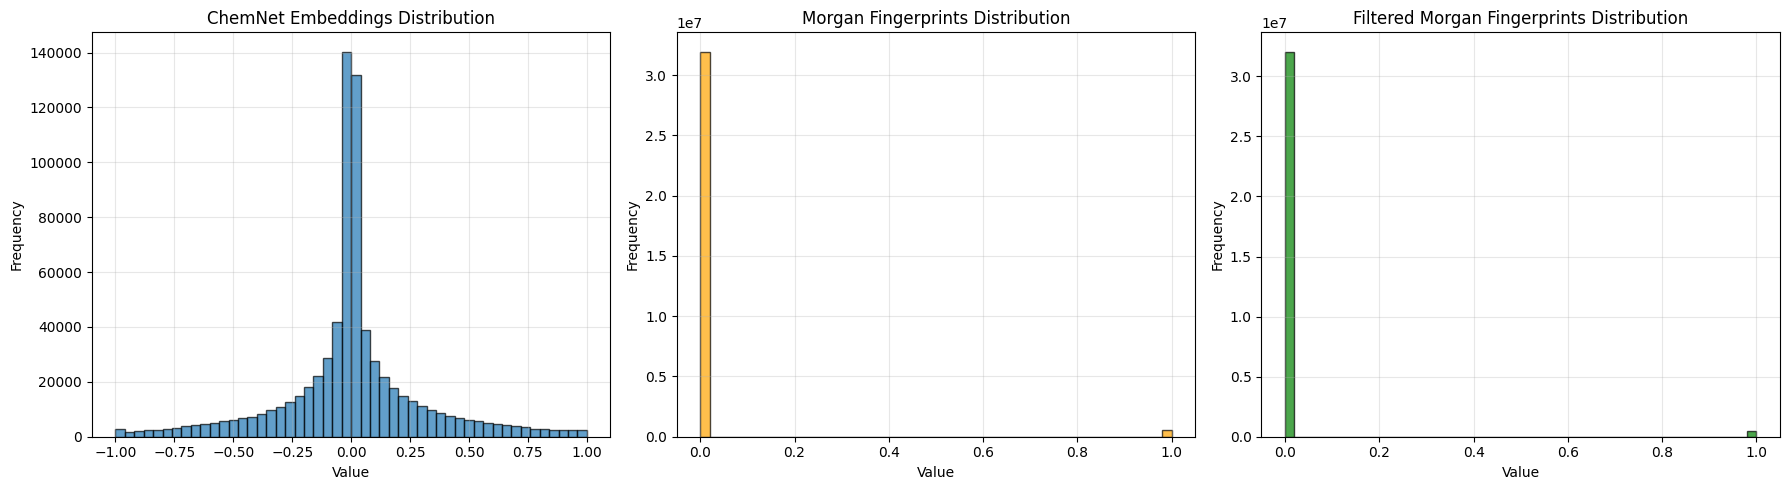

In [5]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram for name_smiles_embedding_df (ChemNet Embeddings)
numerical_cols = name_smiles_embedding_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = name_smiles_embedding_df[numerical_cols].values.flatten()
    axes[0].hist(values, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('ChemNet Embeddings Distribution')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

# Histogram for morgan_df (Morgan Fingerprints)
numerical_cols = morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = morgan_df[numerical_cols].values.flatten()
    axes[1].hist(values, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title('Morgan Fingerprints Distribution')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

# Histogram for filtered_morgan_df (Filtered Morgan Fingerprints)
numerical_cols = filtered_morgan_df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = filtered_morgan_df[numerical_cols].values.flatten()
    axes[2].hist(values, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[2].set_title('Filtered Morgan Fingerprints Distribution')
    axes[2].set_xlabel('Value')
    axes[2].set_ylabel('Frequency')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== name_smiles_embedding_df_noise (ChemNet Embeddings with Noise) ===
Shape: (1419, 513)
Min value: -4.836056
Max value: 4.805108
Mean value: 0.004867

=== morgan_df_noise (Morgan Fingerprints with Noise) ===
Shape: (15869, 2049)
Min value: 0.000000
Max value: 6.223601
Mean value: 0.711510

=== filtered_morgan_df_noise (Filtered Morgan Fingerprints with Noise) ===
Shape: (15869, 2049)
Min value: 0.000000
Max value: 6.449114
Mean value: 0.709252



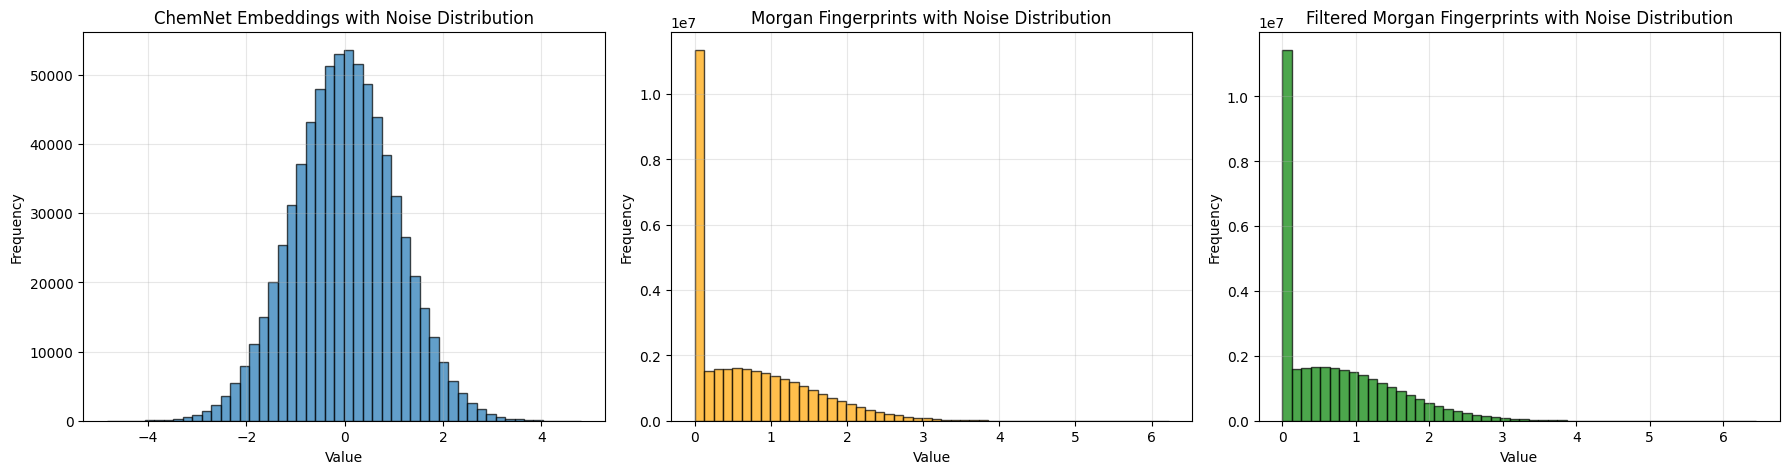


=== FILES SAVED ===
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet


In [ ]:
# Create noisy versions of the dataframes

# 1. ChemNet embeddings with normal noise (mean=0, variance=1)
name_smiles_embedding_df_noise = name_smiles_embedding_df.copy()
numerical_cols = name_smiles_embedding_df_noise.select_dtypes(include=[np.number]).columns
noise = np.random.normal(loc=0, scale=1, size=name_smiles_embedding_df_noise[numerical_cols].shape)
name_smiles_embedding_df_noise[numerical_cols] = name_smiles_embedding_df_noise[numerical_cols] + noise

# 2. Morgan fingerprints with normal noise (mean=0.5, variance=1, no negatives)
morgan_df_noise = morgan_df.copy()
numerical_cols = morgan_df_noise.select_dtypes(include=[np.number]).columns
noise = np.random.normal(loc=0.5, scale=1, size=morgan_df_noise[numerical_cols].shape)
morgan_df_noise[numerical_cols] = morgan_df_noise[numerical_cols] + noise
morgan_df_noise[numerical_cols] = morgan_df_noise[numerical_cols].clip(lower=0)  # Exclude negative values

# 3. Filtered Morgan fingerprints with normal noise (mean=0.5, variance=1, no negatives)
filtered_morgan_df_noise = filtered_morgan_df.copy()
numerical_cols = filtered_morgan_df_noise.select_dtypes(include=[np.number]).columns
noise = np.random.normal(loc=0.5, scale=1, size=filtered_morgan_df_noise[numerical_cols].shape)
filtered_morgan_df_noise[numerical_cols] = filtered_morgan_df_noise[numerical_cols] + noise
filtered_morgan_df_noise[numerical_cols] = filtered_morgan_df_noise[numerical_cols].clip(lower=0)  # Exclude negative values

# Print details for each noisy dataframe
print("=== name_smiles_embedding_df_noise (ChemNet Embeddings with Noise) ===")
print(f"Shape: {name_smiles_embedding_df_noise.shape}")
numerical_cols = name_smiles_embedding_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {name_smiles_embedding_df_noise[numerical_cols].min().min():.6f}")
    print(f"Max value: {name_smiles_embedding_df_noise[numerical_cols].max().max():.6f}")
    print(f"Mean value: {name_smiles_embedding_df_noise[numerical_cols].mean().mean():.6f}")
print()

print("=== morgan_df_noise (Morgan Fingerprints with Noise) ===")
print(f"Shape: {morgan_df_noise.shape}")
numerical_cols = morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {morgan_df_noise[numerical_cols].min().min():.6f}")
    print(f"Max value: {morgan_df_noise[numerical_cols].max().max():.6f}")
    print(f"Mean value: {morgan_df_noise[numerical_cols].mean().mean():.6f}")
print()

print("=== filtered_morgan_df_noise (Filtered Morgan Fingerprints with Noise) ===")
print(f"Shape: {filtered_morgan_df_noise.shape}")
numerical_cols = filtered_morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print(f"Min value: {filtered_morgan_df_noise[numerical_cols].min().min():.6f}")
    print(f"Max value: {filtered_morgan_df_noise[numerical_cols].max().max():.6f}")
    print(f"Mean value: {filtered_morgan_df_noise[numerical_cols].mean().mean():.6f}")
print()

# Create histograms for the noisy dataframes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram for name_smiles_embedding_df_noise
numerical_cols = name_smiles_embedding_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = name_smiles_embedding_df_noise[numerical_cols].values.flatten()
    axes[0].hist(values, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_title('ChemNet Embeddings with Noise Distribution')
    axes[0].set_xlabel('Value')
    axes[0].set_ylabel('Frequency')
    axes[0].grid(True, alpha=0.3)

# Histogram for morgan_df_noise
numerical_cols = morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = morgan_df_noise[numerical_cols].values.flatten()
    axes[1].hist(values, bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_title('Morgan Fingerprints with Noise Distribution')
    axes[1].set_xlabel('Value')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)

# Histogram for filtered_morgan_df_noise
numerical_cols = filtered_morgan_df_noise.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    values = filtered_morgan_df_noise[numerical_cols].values.flatten()
    axes[2].hist(values, bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[2].set_title('Filtered Morgan Fingerprints with Noise Distribution')
    axes[2].set_xlabel('Value')
    axes[2].set_ylabel('Frequency')
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# # Save the noisy dataframes
# name_smiles_embedding_df_noise.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet', index=False)
# morgan_df_noise.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet', index=False)
# filtered_morgan_df_noise.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet', index=False)

print("\n=== FILES SAVED ===")
print("Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet")
print("Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet")
print("Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet")


=== FILES SAVED ===
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp_noise.parquet
Saved: /home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp_noise.parquet


# Testing create_dataset_tensors_condenc_1234e1e2_class function

In [ ]:
# Load the required dataframes
print("Loading required dataframes...")
embedding_df = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_chemnet.parquet')
morgan_df = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_morganfp.parquet')
filtered_morgan_df = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_filtered_morganfp.parquet')

print(f"Embedding df shape: {embedding_df.shape}")
print(f"Morgan df shape: {morgan_df.shape}")
print(f"Filtered Morgan df shape: {filtered_morgan_df.shape}")
print(f"Main df shape: {df.shape}")

# Set up device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Check what columns we have in df
print(f"\nColumns in df: {list(df.columns)}")
print(f"EPA level columns present: {[col for col in df.columns if 'EPA_level' in col]}")

In [ ]:
# Load df6_spectra to get missing columns
df6_spectra = pd.read_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df6_spectra.parquet')

# Add index column if not present
if 'index' not in df.columns:
    df['index'] = df.reset_index(drop=True).index
    print("Added index column to df")

# Check for required columns
required_cols = ['SMILES_spectra', 'Group', 'CE_clean']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"Missing required columns: {missing_cols}")
    print("Retrieving missing columns from df6_spectra using index mapping...")
    
    # Create mapping dictionaries from df6_spectra using index_id
    if 'index_id' in df6_spectra.columns and 'index_id' in df.columns:
        # Use index_id for mapping
        for col in missing_cols:
            if col in df6_spectra.columns:
                mapping_dict = df6_spectra.set_index('index_id')[col].to_dict()
                df[col] = df['index_id'].map(mapping_dict)
                print(f"Added {col} column using index_id mapping")
    else:
        print("Warning: index_id column not found, cannot retrieve missing columns")

# # Take a small sample for testing (first 100 rows)
# df_sample = df.head(100).copy()
# print(f"Testing with sample of {len(df_sample)} rows")

# Take a small sample for testing (first 100 rows)S
df_sample = df.copy()
print(f"Testing with sample of {len(df_sample)} rows")

# Verify all required columns are now present
final_missing = [col for col in required_cols if col not in df_sample.columns]
if final_missing:
    print(f"Still missing columns: {final_missing}")
else:
    print("All required columns are now present!")


In [ ]:
df_sample.head()

In [ ]:
# Call the function
print("\nCalling create_dataset_tensors_condenc_1234e1e2_class function...")
try:
    spectra_with_ext_tensor, embeddings_tensor, tox_class_indices, morgan_tensor, filtered_morgan_tensor, spectra_indices_tensor = fd.create_dataset_tensors_condenc_1234e1e2_class(
        spectra_dataset=df_sample,
        embedding_df=embedding_df,
        morgan_df=morgan_df,
        filtered_morgan_df=filtered_morgan_df,
        device=device,
        start_idx=1,  # Skip SMILES column
        stop_idx=-10   # Stop before metadata columns
    )
    
    print("Function executed successfully!")
    
except Exception as e:
    print(f"Error occurred: {str(e)}")
    import traceback
    traceback.print_exc()

In [ ]:
# Examine the output tensors
print("=== TENSOR ANALYSIS ===")
print(f"Device: {device}")
print()

print("1. Spectra with Extensions Tensor:")
print(f"   Shape: {spectra_with_ext_tensor.shape}")
print(f"   Data type: {spectra_with_ext_tensor.dtype}")
print(f"   Device: {spectra_with_ext_tensor.device}")
print(f"   Min value: {spectra_with_ext_tensor.min().item():.6f}")
print(f"   Max value: {spectra_with_ext_tensor.max().item():.6f}")
print(f"   Mean value: {spectra_with_ext_tensor.mean().item():.6f}")
print()

print("2. Embeddings Tensor:")
print(f"   Shape: {embeddings_tensor.shape}")
print(f"   Data type: {embeddings_tensor.dtype}")
print(f"   Device: {embeddings_tensor.device}")
print(f"   Min value: {embeddings_tensor.min().item():.6f}")
print(f"   Max value: {embeddings_tensor.max().item():.6f}")
print(f"   Mean value: {embeddings_tensor.mean().item():.6f}")
print()

print("3. Toxicity Class Indices Tensor:")
print(f"   Shape: {tox_class_indices.shape}")
print(f"   Data type: {tox_class_indices.dtype}")
print(f"   Device: {tox_class_indices.device}")
print(f"   Unique classes: {torch.unique(tox_class_indices).cpu().numpy()}")
print(f"   Class counts: {torch.bincount(tox_class_indices).cpu().numpy()}")
print(f"   Min class: {tox_class_indices.min().item()}")
print(f"   Max class: {tox_class_indices.max().item()}")
print()

print("4. Morgan Tensor:")
print(f"   Shape: {morgan_tensor.shape}")
print(f"   Data type: {morgan_tensor.dtype}")
print(f"   Device: {morgan_tensor.device}")
print(f"   Min value: {morgan_tensor.min().item():.6f}")
print(f"   Max value: {morgan_tensor.max().item():.6f}")
print(f"   Mean value: {morgan_tensor.mean().item():.6f}")
print()

print("5. Filtered Morgan Tensor:")
print(f"   Shape: {filtered_morgan_tensor.shape}")
print(f"   Data type: {filtered_morgan_tensor.dtype}")
print(f"   Device: {filtered_morgan_tensor.device}")
print(f"   Min value: {filtered_morgan_tensor.min().item():.6f}")
print(f"   Max value: {filtered_morgan_tensor.max().item():.6f}")
print(f"   Mean value: {filtered_morgan_tensor.mean().item():.6f}")
print()

print("6. Spectra Indices Tensor:")
print(f"   Shape: {spectra_indices_tensor.shape}")
print(f"   Data type: {spectra_indices_tensor.dtype}")
print(f"   Device: {spectra_indices_tensor.device}")
print(f"   Min index: {spectra_indices_tensor.min().item()}")
print(f"   Max index: {spectra_indices_tensor.max().item()}")
print(f"   First 10 indices: {spectra_indices_tensor[:10].cpu().numpy()}")

In [ ]:
# Additional validation checks
print("=== VALIDATION CHECKS ===")

# Check if tensor shapes are consistent
n_samples = len(df_sample)
print(f"Expected number of samples: {n_samples}")

# Check tensor shape consistency
tensor_shapes_consistent = all([
    spectra_with_ext_tensor.shape[0] == n_samples,
    embeddings_tensor.shape[0] == n_samples,
    tox_class_indices.shape[0] == n_samples,
    morgan_tensor.shape[0] == n_samples,
    filtered_morgan_tensor.shape[0] == n_samples,
    spectra_indices_tensor.shape[0] == n_samples
])
print(f"All tensors have consistent first dimension: {tensor_shapes_consistent}")

# Check EPA levels in original data vs tensor classes
print(f"\nEPA level distribution in original data:")
if 'EPA_level' in df_sample.columns:
    original_classes = df_sample['EPA_level'].value_counts().sort_index()
    print(original_classes)
elif any(col.startswith('EPA_level') for col in df_sample.columns if col != 'EPA_level'):
    epa_cols = [col for col in df_sample.columns if col.startswith('EPA_level') and col != 'EPA_level']
    original_classes = df_sample[epa_cols].idxmax(axis=1).str.replace('EPA_level_', '').astype(int).value_counts().sort_index()
    print(original_classes)

print(f"\nTensor class distribution:")
tensor_classes = torch.bincount(tox_class_indices).cpu().numpy()
for i, count in enumerate(tensor_classes):
    if count > 0:
        print(f"Class {i}: {count} samples")

# Sample a few examples to verify correctness
print(f"\n=== SAMPLE VERIFICATION ===")
sample_indices = [0, 1, 2]  # Check first 3 samples
for i in sample_indices:
    print(f"\nSample {i}:")
    print(f"  SMILES: {df_sample.iloc[i]['SMILES_spectra']}")
    if 'EPA_level' in df_sample.columns:
        print(f"  Original EPA level: {df_sample.iloc[i]['EPA_level']}")
        print(f"  Tensor class (0-based): {tox_class_indices[i].item()}")
    print(f"  Group: {df_sample.iloc[i]['Group']}")
    print(f"  CE_clean: {df_sample.iloc[i]['CE_clean']}")
    print(f"  Input tensor first 5 values: {spectra_with_ext_tensor[i][:5].cpu().numpy()}")
    print(f"  Embedding tensor first 5 values: {embeddings_tensor[i][:5].cpu().numpy()}")
    print(f"  Morgan tensor first 5 values: {morgan_tensor[i][:5].cpu().numpy()}")

In [ ]:
# Verify EPA level to tensor class mapping
print("=== EPA LEVEL TO TENSOR CLASS MAPPING ===")

# Check what EPA levels we have in the original dataframe
print("EPA levels in original dataframe:")
if 'EPA_level' in df_sample.columns:
    epa_distribution = df_sample['EPA_level'].value_counts().sort_index()
    print(epa_distribution)
    print(f"EPA levels present: {sorted(df_sample['EPA_level'].unique())}")
elif any(col.startswith('EPA_level') for col in df_sample.columns if col != 'EPA_level'):
    epa_cols = [col for col in df_sample.columns if col.startswith('EPA_level') and col != 'EPA_level']
    print(f"One-hot EPA columns found: {epa_cols}")
    epa_levels = df_sample[epa_cols].idxmax(axis=1).str.replace('EPA_level_', '').astype(int)
    epa_distribution = epa_levels.value_counts().sort_index()
    print(epa_distribution)
    print(f"EPA levels present: {sorted(epa_levels.unique())}")

print(f"\nTensor class distribution (0-indexed):")
tensor_classes = torch.bincount(tox_class_indices).cpu().numpy()
for i, count in enumerate(tensor_classes):
    print(f"Tensor Class {i}: {count} samples")

print(f"\nMapping verification:")
print("If EPA levels 1,2,3,4 map to tensor classes 0,1,2,3:")
for i, count in enumerate(tensor_classes):
    print(f"EPA_level_{i+1} → Tensor Class {i}: {count} samples")
    
print(f"\nConclusion: There are {tensor_classes[0]} EPA_level_1 spectra in this dataset.")